# T cell annotation
Lingting Shi, Azizi lab, Columbia University

In [1]:
import anndata
import numpy as np
import pandas as pd
#from matplotlib_venn import venn2
from glob import glob

import scanpy as sc
import anndata as ad
import anndata
import pickle
import matplotlib.pyplot as plt

from tqdm import tqdm
import gc
import tarfile
#import scirpy as ir
import collections
from glob import glob
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import anndata
import pickle
import matplotlib.pyplot as plt
from tqdm import tqdm
import gc
import tarfile
#import community.community_louvain as community_louvain
import networkx as nx
from sklearn.neighbors import kneighbors_graph
from scipy import stats
import seaborn as sns
import collections
import random
from scipy.stats import zscore
#from kneed import KneeLocator
random.seed(10)

In [2]:
tcell_ann_concat = anndata.read_h5ad('/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/anndata_file/tcell_ann_concat_Tcell_only.h5ad')

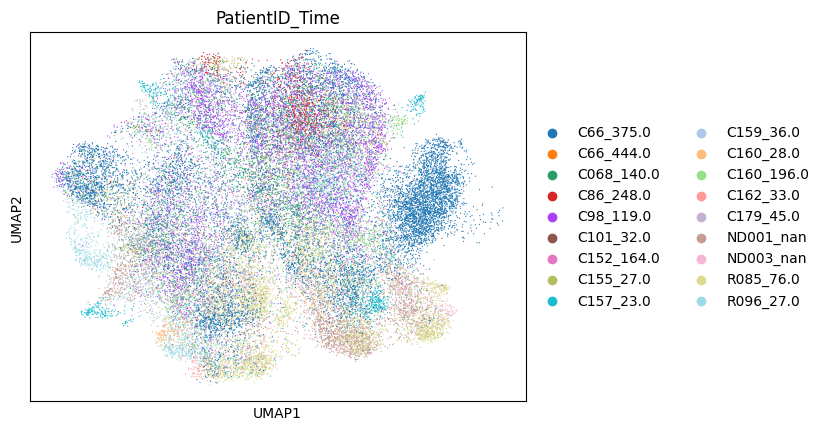

In [3]:
##### Update some meta data infromation
tcell_ann_concat.obs.loc[tcell_ann_concat.obs['PatientID']=='C179','GVHD_Grade_1'] = "Mild"
tcell_ann_concat.obs.loc[tcell_ann_concat.obs['PatientID']=='R085','GVHD_Grade_1'] = "No"

tcell_ann_concat.obs['GVHD_Grade_1'] = tcell_ann_concat.obs['GVHD_Grade_1'].astype('category')
#tcell_ann_concat.obs['GVHD_Grade_1'] = tcell_ann_concat.obs['GVHD_Grade_1'].cat.add_categories(['Treated']) ### Let us call it No instead
tcell_ann_concat.obs.loc[tcell_ann_concat.obs['Days_post-Transplant']==444.0,'GVHD_Grade_1'] = "No"

tcell_ann_concat.obs['PatientID_Time'] = tcell_ann_concat.obs['PatientID'].astype(str)+'_'+tcell_ann_concat.obs['Days_post-Transplant'].astype(str)

sc.pl.umap(tcell_ann_concat, color=['PatientID_Time'],ncols=2)

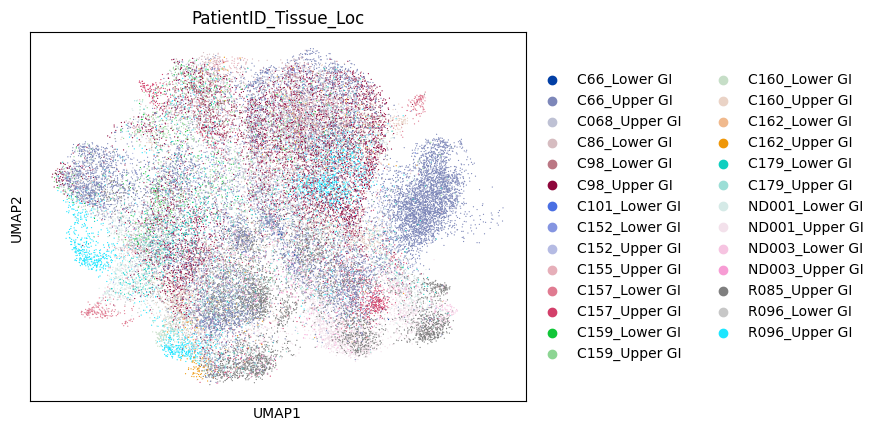

In [4]:
tcell_ann_concat.obs['PatientID_Tissue_Loc'] = tcell_ann_concat.obs['PatientID'].astype(str)+'_'+tcell_ann_concat.obs['Tissue_Location'].astype(str)

tcell_ann_concat.obs['PatientID_Tissue_Loc'] = tcell_ann_concat.obs['PatientID'].astype(str)+'_'+tcell_ann_concat.obs['Tissue_Location'].astype(str)

# Update Location specific or Day specific meta data
tcell_ann_concat.obs.loc[tcell_ann_concat.obs['PatientID_Tissue_Loc']=='C162_Upper GI','GVHD_Grade_1'] = "No"
tcell_ann_concat.obs.loc[tcell_ann_concat.obs['PatientID_Time']=='C160_28.0','GVHD_Grade_1'] = "Mild"
tcell_ann_concat.obs.loc[tcell_ann_concat.obs['PatientID_Time']=='C160_196.0','GVHD_Grade_1'] = "No"

tcell_ann_concat.obs['PatientID_Grade'] = tcell_ann_concat.obs['PatientID'].astype(str)+'_'+tcell_ann_concat.obs['GVHD_Grade_1'].astype(str)

sc.pl.umap(tcell_ann_concat, color=['PatientID_Tissue_Loc'],ncols=2)

In [5]:
tcell_ann_concat.obs['PatientID_Grade_Time_Loc'] = tcell_ann_concat.obs['PatientID'].astype(str)+'_'+tcell_ann_concat.obs['GVHD_Grade_1'].astype(str)+'_'+tcell_ann_concat.obs['Days_post-Transplant'].astype(str)+'_'+tcell_ann_concat.obs['Tissue_Location'].astype(str)

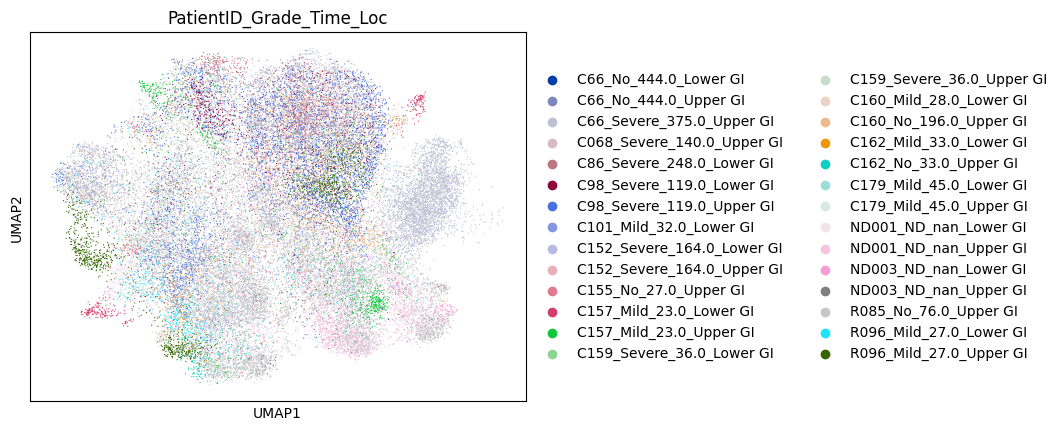

In [6]:
sc.pl.umap(tcell_ann_concat, color=['PatientID_Grade_Time_Loc'],ncols=2)

In [7]:
### Remove small clusters
# Get the value counts
cluster_counts = tcell_ann_concat.obs['leiden_0.5'].value_counts()

# Filter out clusters with counts lower than 200
filtered_clusters = cluster_counts[cluster_counts >= 200]

# Get the names of the clusters to keep
clusters_to_keep = filtered_clusters.index

# Filter the AnnData object to keep only the cells in those clusters
filtered_tcell_ann_concat = tcell_ann_concat[tcell_ann_concat.obs['leiden_0.5'].isin(clusters_to_keep)]

# Optionally, view the filtered counts
filtered_counts = filtered_tcell_ann_concat.obs['leiden_0.5'].value_counts()
filtered_counts

tcell_ann_concat = filtered_tcell_ann_concat

# Figure 4C

/Users/lingting/ENTER/envs/mrvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1071: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  self.obs[key] = self.obs[key].cat.rename_categories(categories)


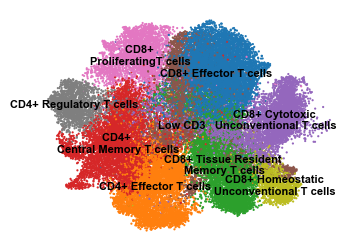

In [8]:
import matplotlib as mpl
# Update your existing rcParams
mpl.rcParams.update({
    'font.size': 8,
    'svg.fonttype': 'none',
    'font.family': 'Arial',
    'figure.figsize': (4, 3)  # Set default figure size to 6×4 inches
})
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['xtick.labelsize'] = 8  # Colorbar tick label size 
mpl.rcParams['ytick.labelsize'] = 8  # Colorbar tick label size


# New cluster names
new_cluster_names = ['CD8+ Effector T cells','CD4+ Effector T cells','CD8+ Tissue Resident \nMemory T cells', "CD4+ \nCentral Memory T cells","CD8+ Cytotoxic \nUnconventional T cells",'Low CD3',"CD8+ \nProliferatingT cells","CD4+ Regulatory T cells",'CD8+ Homeostatic \nUnconventional T cells '
]

# Rename clusters
tcell_ann_concat.rename_categories('leiden_0.5', new_cluster_names)

# Generate UMAP plot with larger dots
sc.pl.umap(
    tcell_ann_concat,
    color='leiden_0.5',
    legend_loc='on data',
    title='',
    frameon=False,
    size=10,  # Adjust this value to make the dots bigger (default is 120)
    show=False  # We will save it manually
)

# Save the plot manually with DPI 300
plt.savefig('/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/umap_clusters_dpi300.pdf', dpi=300, bbox_inches='tight', transparent = True)
plt.savefig('//Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/umap_clusters_dpi300.png', dpi=300, bbox_inches='tight', transparent = True)
plt.savefig('//Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/umap_clusters_dpi300.svg', dpi=300, bbox_inches='tight', transparent = True)
# Show the plot (optional, if you want to see it before saving)
plt.show()

In [9]:
###### Filter out samples with low cell count
# Calculate cell counts per sample
cell_counts = tcell_ann_concat.obs['SampleID'].value_counts()

# Get samples with at least 100 cells
valid_samples = cell_counts[cell_counts >= 100].index

# Subset AnnData to retain only valid samples
tcell_ann_concat_f = tcell_ann_concat[tcell_ann_concat.obs['SampleID'].isin(valid_samples), :]

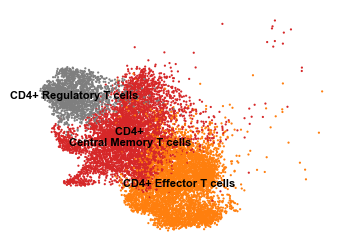

In [10]:
# Generate UMAP plot with larger dots
sc.pl.umap(
    tcell_ann_concat_f[tcell_ann_concat_f.obs['leiden_0.5'].isin(['CD4+ Effector T cells',"CD4+ Regulatory T cells",  "CD4+ \nCentral Memory T cells"])],
    color='leiden_0.5',
    legend_loc='on data',
    title='',
    frameon=False,
    size=10,  # Adjust this value to make the dots bigger (default is 120)
    show=False  # We will save it manually
)

# Save the plot manually with DPI 300
plt.savefig(f'/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/umap_clusters_cd4_dpi300.pdf', dpi=300, bbox_inches='tight', transparent = True)
plt.savefig(f'//Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/umap_clusters_cd4_dpi300.png', dpi=300, bbox_inches='tight', transparent = True)
plt.savefig(f'/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/umap_clusters_cd4_dpi300.svg', dpi=300, bbox_inches='tight', transparent = True)
# Show the plot (optional, if you want to see it before saving)
plt.show()

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_79553/2520016422.py:5: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  tcell_ann_concat_f.obs["GVHD_Grade_1"] = pd.Categorical(


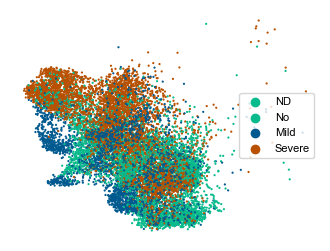

In [11]:

# Define the order you want
desired_order = ['ND','No', 'Mild', 'Severe']  # Adjust based on your data

# Convert to categorical with specified order
tcell_ann_concat_f.obs["GVHD_Grade_1"] = pd.Categorical(
    tcell_ann_concat_f.obs["GVHD_Grade_1"],
    categories=desired_order,
    ordered=True
)
tcell_ann_concat_f.uns["GVHD_Grade_1_colors"] = ['#09BB8C','#09BB8C','#005A8F', '#B85000']
# Generate UMAP plot with larger dots
sc.pl.umap(
    tcell_ann_concat_f[tcell_ann_concat_f.obs['leiden_0.5'].isin(['CD4+ Effector T cells',"CD4+ Regulatory T cells",  "CD4+ \nCentral Memory T cells"])],
    color='GVHD_Grade_1',
    legend_loc='right',
    title='',
    frameon=False,
    size=10,  # Adjust this value to make the dots bigger (default is 120)
    show=False  # We will save it manually
)

# Save the plot manually with DPI 300
plt.savefig(f'/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/umap_clusters_cd4_grade_dpi300.pdf', dpi=300, bbox_inches='tight', transparent = True)
plt.savefig(f'//Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/umap_clusters_cd4_grade_dpi300.png', dpi=300, bbox_inches='tight', transparent = True)
plt.savefig(f'/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/umap_clusters_cd4_grade_dpi300.svg', dpi=300, bbox_inches='tight', transparent = True)
# Show the plot (optional, if you want to see it before saving)
plt.show()

In [12]:
tcell_ann_concat.uns['leiden_0.5_colors']

array(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b',
       '#e377c2', '#7f7f7f', '#bcbd22'], dtype=object)

In [13]:
tcell_ann_concat.obs['leiden_0.5']

AAACCTGGTTGGAGGT-1      CD4+ \nCentral Memory T cells
AAACCTGTCTATCCTA-1              CD8+ Effector T cells
AAACGGGAGGATGCGT-1              CD8+ Effector T cells
AAACGGGGTAAATGAC-1              CD8+ Effector T cells
AAAGATGCAAACTGTC-1              CD8+ Effector T cells
                                    ...              
TGTTCCGAGGACAGCT-1              CD4+ Effector T cells
TTAGGACGTTGTTTGG-1                            Low CD3
TTAGGACTCCCAAGAT-1              CD4+ Effector T cells
TTCGAAGTCCGCATCT-1-1            CD4+ Effector T cells
TTGCGTCCAAGAAAGG-1              CD4+ Effector T cells
Name: leiden_0.5, Length: 38766, dtype: category
Categories (9, object): ['CD8+ Effector T cells', 'CD4+ Effector T cells', 'CD8+ Tissue Resident \nMemory T cells', 'CD4+ \nCentral Memory T cells', ..., 'Low CD3', 'CD8+ \nProliferatingT cells', 'CD4+ Regulatory T cells', 'CD8+ Homeostatic \nUnconventional T cells ']

# Figure 4F

In [14]:
category_order = ['ND', 'No', 'Mild', 'Severe']

ND


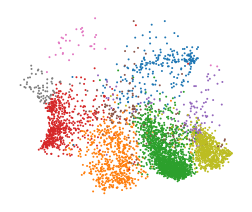

No


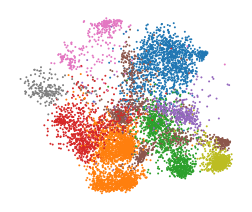

Mild


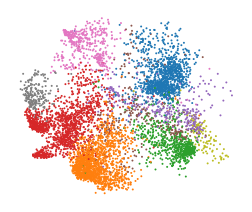

Severe


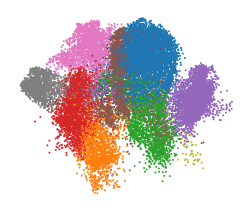

In [15]:
import matplotlib as mpl
# Update your existing rcParams
mpl.rcParams.update({
    'font.size': 8,
    'svg.fonttype': 'none',
    'font.family': 'Arial',
    'figure.figsize': (3, 2.5)  # Set default figure size to 6×4 inches
})
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['xtick.labelsize'] = 8  # Colorbar tick label size 
mpl.rcParams['ytick.labelsize'] = 8  # Colorbar tick label size

# New cluster names
new_cluster_names = [
    'CD8+ Effector T cells', 'CD4+ Effector T cells', 
    'CD8+ Tissue Resident Memory T cells', "CD4+ Central Memory T cells",
    "CD8+ Cytotoxic Unconventional T cells", 'Low CD3', 
    "CD8+ Proliferating T cells", "CD4+ Regulatory T cells",
    'CD8+ Homeostatic Unconventional T cells'
]

tcell_ann_concat.rename_categories('leiden_0.5', new_cluster_names)

for cat in category_order:
    print(cat)
    # Generate UMAP plot with larger dots and transparency
    sc.pl.umap(
        tcell_ann_concat[tcell_ann_concat.obs['GVHD_Grade_1']== cat],
        color='leiden_0.5',
        title='',
        frameon=False,
        size=8,  # Adjust this value to make the dots bigger (default is 120)
        show=False,  # We will save it manually
        legend_loc=None
    )

    # Save the plot manually with DPI 300
    plt.savefig(f'/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/umap_clusters_dpi300_presentation_{cat}.pdf', dpi=300, bbox_inches='tight', transparent = True)
    plt.savefig(f'/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/umap_clusters_dpi300_presentation_{cat}.png', dpi=300, bbox_inches='tight', transparent = True)
    plt.savefig(f'/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/umap_clusters_dpi300_presentation_{cat}.svg', dpi=300, bbox_inches='tight', transparent = True)
# Show the plot (optional, if you want to see it before saving)
    plt.show()

# Heatmaps and dot plots for each cluster

In [16]:
new_cluster_names = ['CD8+ Effector T cells','CD4+ Effector T cells','CD8+ Tissue Resident Memory T cells', "CD4+ Central Memory T cells","CD8+ Cytotoxic Unconventional T cells",'Low CD3',"CD8+ Proliferating T cells","CD4+ Regulatory T cells",'CD8+ Homeostatic Unconventional T cells'
]
tcell_ann_concat.rename_categories('leiden_0.5', new_cluster_names)

In [17]:
# Replace 'CATEGORY_NAME' with the actual name of the categorical field in .obs
category_name = 'leiden_0.5'

# Check if the color map exists in `.uns`
if f"{category_name}_colors" in tcell_ann_concat.uns:
    category_colors = tcell_ann_concat.uns[f"{category_name}_colors"]
    print(category_colors)
else:
    print(f"No colors found for category {category_name}.")

# Extract the category values
categories = tcell_ann_concat.obs[category_name].cat.categories

# Pair colors with category values
color_map = dict(zip(categories, category_colors))
print(color_map)

['#1f77b4' '#ff7f0e' '#2ca02c' '#d62728' '#9467bd' '#8c564b' '#e377c2'
 '#7f7f7f' '#bcbd22']
{'CD8+ Effector T cells': '#1f77b4', 'CD4+ Effector T cells': '#ff7f0e', 'CD8+ Tissue Resident Memory T cells': '#2ca02c', 'CD4+ Central Memory T cells': '#d62728', 'CD8+ Cytotoxic Unconventional T cells': '#9467bd', 'Low CD3': '#8c564b', 'CD8+ Proliferating T cells': '#e377c2', 'CD4+ Regulatory T cells': '#7f7f7f', 'CD8+ Homeostatic Unconventional T cells': '#bcbd22'}


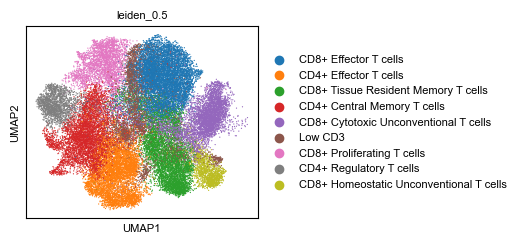

In [18]:
sc.pl.umap(tcell_ann_concat, color=['leiden_0.5'])

# Figure 4F

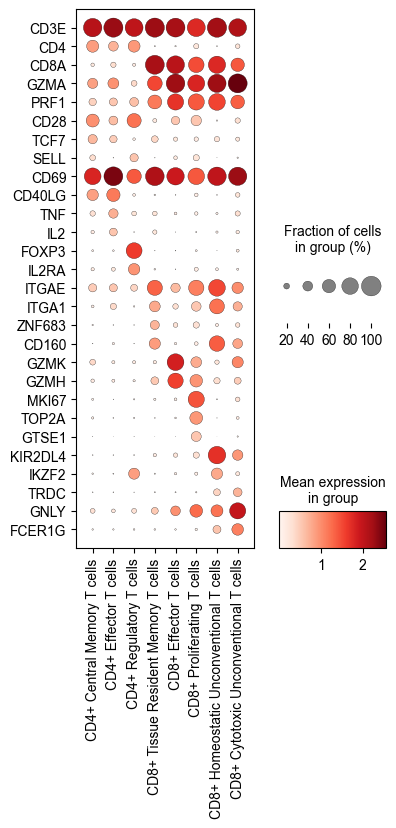

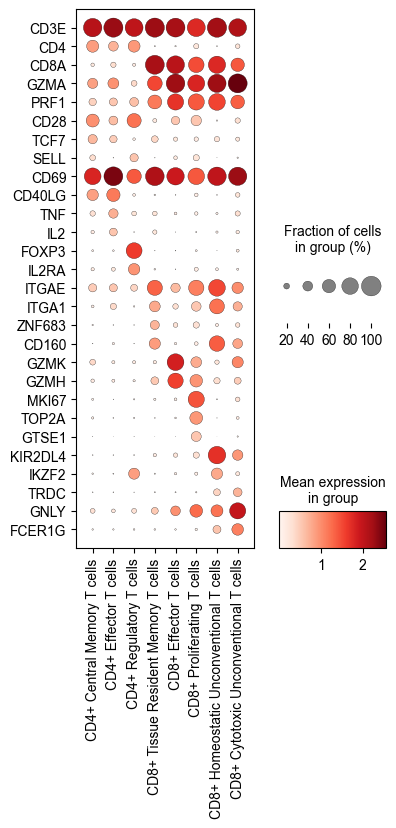

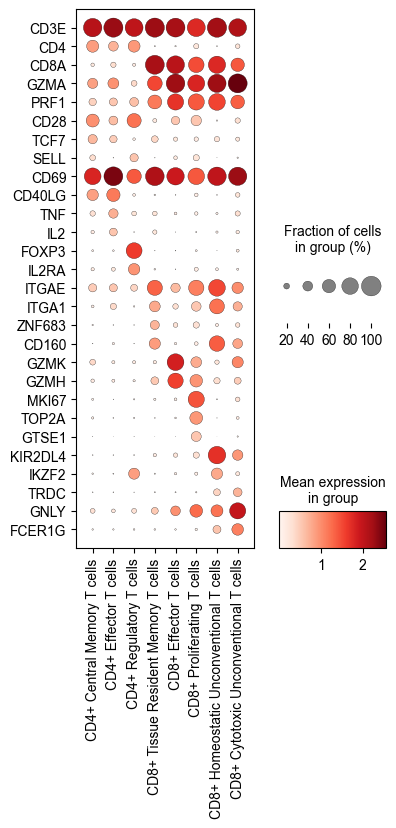

In [19]:
import pandas as pd

# Specify the desired order
desired_order = ["CD4+ Central Memory T cells",'CD4+ Effector T cells', "CD4+ Regulatory T cells", 'CD8+ Tissue Resident Memory T cells',"CD8+ Effector T cells", "CD8+ Proliferating T cells",'CD8+ Homeostatic Unconventional T cells', "CD8+ Cytotoxic Unconventional T cells", 'Low CD3']

# Reorder the categories in the `groupby` column
tcell_ann_concat.obs['leiden_0.5_reordered'] = tcell_ann_concat.obs['leiden_0.5'].astype(pd.CategoricalDtype(categories=desired_order, ordered=True))

## For publication
import matplotlib as mpl
import matplotlib as mpl
# Update your existing rcParams
mpl.rcParams.update({
    'font.size': 12,
    'svg.fonttype': 'none',
    'font.family': 'Arial',
    #'figure.figsize': (4, 3),  # Set default figure size to 6×4 inches
    'lines.linewidth': 1.2  # Set default line width to 1
})
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['xtick.labelsize'] = 12  # Colorbar tick label size 
mpl.rcParams['ytick.labelsize'] = 12  # Colorbar tick label size


# Plot each marker set one at a time and save the figures manually
# Generate the dot plot and return the figure
dotplot = sc.pl.dotplot(
    tcell_ann_concat[tcell_ann_concat.obs['leiden_0.5'] != 'Low CD3'], 
    var_names=["CD3E",'CD4','CD8A',"GZMA",'PRF1','CD28', 'TCF7','SELL','CD69', 'CD40LG', 'TNF', 'IL2', "FOXP3",'IL2RA','ITGAE', 'ITGA1','ZNF683', 'CD160','GZMK','GZMH','MKI67', 'TOP2A','GTSE1', 'KIR2DL4', 'IKZF2', 'TRDC', 'GNLY', 'FCER1G'], 
    groupby='leiden_0.5_reordered', 
    dendrogram=False, 
    title='',
    return_fig=True,  # Return the figure object for saving
    swap_axes=True,
    figsize=(4,7),
    dot_max = 1

)

    
# Save the figure with the specified DPI
dotplot.savefig('/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/dotplot_cluster_sign_presentation.png', dpi=300, bbox_inches='tight')
dotplot.savefig('/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/dotplot_cluster_sign_presentation.pdf', dpi=300, bbox_inches='tight')
dotplot.savefig('/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/dotplot_cluster_sign_presentation.svg', dpi=300, bbox_inches='tight')
# Show the plot (optional)

plt.show()

                      leiden_0.5_reordered
0              CD4+ Central Memory T cells
1                    CD4+ Effector T cells
2                  CD4+ Regulatory T cells
3      CD8+ Tissue Resident Memory T cells
4                    CD8+ Effector T cells
5               CD8+ Proliferating T cells
6  CD8+ Homeostatic Unconventional T cells
7    CD8+ Cytotoxic Unconventional T cells


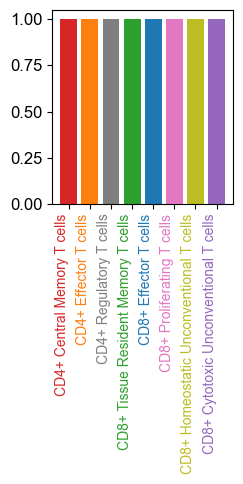

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
mpl.rcParams.update({
    'font.size': 12,
    'svg.fonttype': 'none',
    'font.family': 'Arial',
    'figure.figsize': (2.5, 5),  # Set default figure size to 6×4 inches
    'lines.linewidth': 1.2  # Set default line width to 1
})
desired_order = ["CD4+ Central Memory T cells",'CD4+ Effector T cells', "CD4+ Regulatory T cells", 'CD8+ Tissue Resident Memory T cells',"CD8+ Effector T cells", "CD8+ Proliferating T cells",'CD8+ Homeostatic Unconventional T cells', "CD8+ Cytotoxic Unconventional T cells"]

# Create a mock observation dataframe
# Replace this with your actual data from `tcell_ann_concat.obs`
obs_data = pd.DataFrame({
    'leiden_0.5_reordered': desired_order
})

print(obs_data)

# Map of categories to colors
color_map = {
    'CD8+ Effector T cells': '#1f77b4', 
    'CD4+ Effector T cells': '#ff7f0e', 
    'CD8+ Tissue Resident Memory T cells': '#2ca02c', 
    'CD4+ Central Memory T cells': '#d62728', 
    'CD8+ Cytotoxic Unconventional T cells': '#9467bd', 
    'Low CD3': '#8c564b', 
    'CD8+ Proliferating T cells': '#e377c2', 
    'CD4+ Regulatory T cells': '#7f7f7f', 
    'CD8+ Homeostatic Unconventional T cells': '#bcbd22'
}

# Set y as 1 for all
x = obs_data['leiden_0.5_reordered']
y = [1] * len(x)  # y-values all set to 1
colors = [color_map[category] for category in x]  # Map colors based on categories

# Create the plot
fig, ax = plt.subplots(figsize=(2.5, 5))
bars = ax.bar(x, y, color=colors)  # Assign bar colors

# Rotate x-axis labels, set colors, and adjust layout
ax.set_xticks(range(len(x)))
ax.set_xticklabels(x, rotation=90, ha='right')  # Rotate labels

# Color the x-axis labels individually
for label, color in zip(ax.get_xticklabels(), colors):
    label.set_color(color)  # Set label color
plt.xticks(fontsize=10)
plt.tight_layout()
# Save the figure with the specified DPI
plt.savefig('/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/dotplot_x-axis_label.png', dpi=900, bbox_inches='tight')
plt.savefig('/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/dotplot_x-axis_label.pdf', dpi=900, bbox_inches='tight')
plt.savefig('/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/dotplot_x-axis_label.svg', dpi=900, bbox_inches='tight')


# Show the plot
plt.show()


In [ ]:
tcell_ann_loc = '/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/anndata_file/tcell_ann_concat_Tcell_only_proportion.h5ad'
tcell_ann_concat.write(tcell_ann_loc)